# Project Scope

**Goals**: 
* To investigate the relationship between GDP and life expectancy of six countries from the provided dataset. To find interesting insights about that relationship.
* To research more deeply the changes in GDP and Life Expectancy values in the case of each country and overall.
* To find the factors that might cause changes in the character of the relationship.

**Data**:
The CSV file provided includes GDP and Life Expectancy data from the World Health Organization and the World Bank for 6 countries: The USA, China, Chile, Germany, Mexico, and Zimbabwe (2000-2015).

**Analysis**:
* Import and inspect the data provided for the research.
* Create plots to understand the relationship between GDP and Life Expectancy for each separate country and for all 6 countries at a time.
* Create plots to understand the changes in GDP and Life Expectancy during the period of time provided in the data for the research.
* Conduct deeper research for the cases that might need it.








# Importing

## Import libraries

In [1]:
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr

## Import CSV and convert to DataFrame

In [2]:
df = pd.read_csv('all_data.csv')

## Inspecting the data

### First five rows of the dataframe

In [3]:
df.head()

,Country,Year,Life expectancy at birth (years),GDP
0,Chile,2000,77.3,7.786093e+10
1,Chile,2001,77.3,7.097992e+10
2,Chile,2002,77.8,6.973681e+10
3,Chile,2003,77.9,7.564346e+10
4,Chile,2004,78.0,9.921039e+10


### Data type of each column

In [4]:
df.dtypes

Country                              object
Year                                  int64
Life expectancy at birth (years)    float64
GDP                                 float64
dtype: object

### Information of all columns

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country                           96 non-null     object 
 1   Year                              96 non-null     int64  
 2   Life expectancy at birth (years)  96 non-null     float64
 3   GDP                               96 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 3.1+ KB


### Lists of unqiue values in Country and Year columns

In [6]:
Countries_list = df.Country.unique()
Years_list = df.Year.unique()
print(Countries_list)
print(Years_list)

['Chile' 'China' 'Germany' 'Mexico' 'United States of America' 'Zimbabwe']
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015]


## EDA

#### GDP & Life Expactancy for each country

In [7]:
#create subsets for each country
Chile = df[df.Country == 'Chile']
China = df[df.Country == 'China']
Germany = df[df.Country == 'Germany']
Mexico = df[df.Country == 'Mexico']
US = df[df.Country == 'United States of America']
Zimbabwe = df[df.Country == 'Zimbabwe']

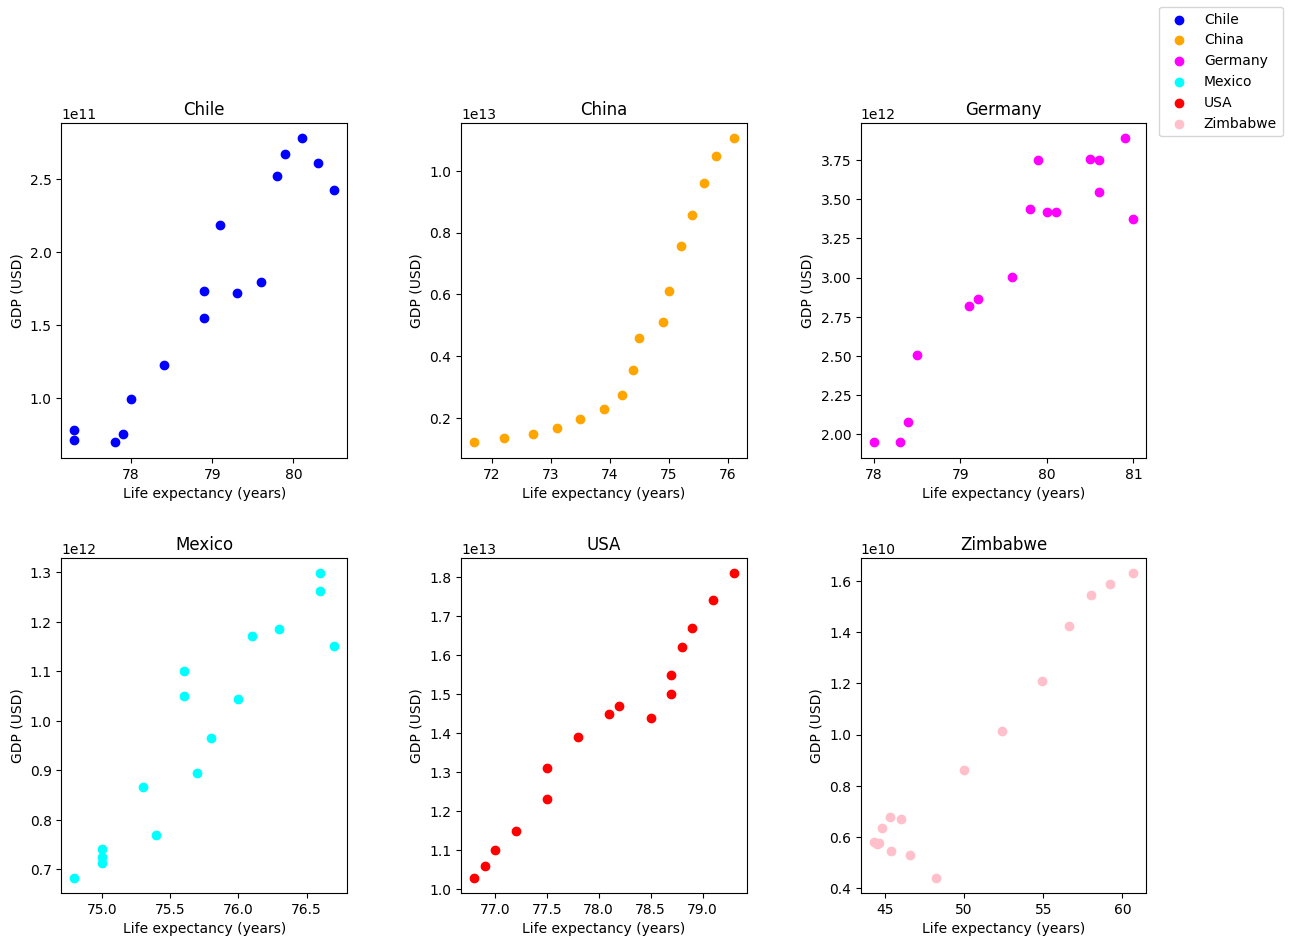

In [8]:
#scatter plot to visualize because there are two quantitave varibles: Life expectancy & GDP
#create scatter plots at subplots for each separate country
countries = [Chile, China, Germany, Mexico, US, Zimbabwe]
names = ['Chile', 'China', 'Germany', 'Mexico', 'USA', 'Zimbabwe']
colors = ['blue', 'orange', 'magenta', 'cyan', 'red', 'pink']
fig = plt.figure(figsize=(14,10))
n=1
for country in countries:
    plt.subplot(2,3,n)
    plt.scatter(x=country['Life expectancy at birth (years)'], y=country['GDP'], color = colors[n-1], label = names[n-1])
    plt.xlabel('Life expectancy (years)')
    plt.ylabel('GDP (USD)')
    plt.title(names[n-1])
    n+=1
plt.subplots_adjust(wspace = 0.4)
plt.subplots_adjust(hspace = 0.3)
fig.legend(loc=1)
plt.show()

##### Comments
* GDP and Life expectancy values for the USA and China  are highly positively correalted.
* For Mexico, Chile and Germany, GDP and Life expectancy values are also positively correlated. However, some parts of the plots for those countries require deeper analysis because of the visual uncertainty of the correlation.
* For Zimbabwe, we see strong positive correlation between GDP and Life expectancy starting from about 50 years. However, before that period, it seems to be even a negative correlation between those two values, which is totally unusual for the other countries of our research. It also requires a deeper analysis
* All in all, on average, the life expectancy seems to be increasing over the years for all countries. 

#### GDP & Life Expactancy for all countries

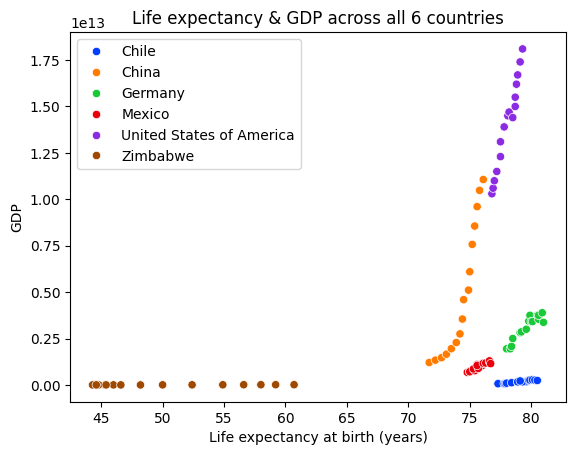

In [9]:
#scatter plot with 3 variables to visualize because there are two quantitative variables: Life expectancy & GDP & one categorical - country
sns.scatterplot(x=df['Life expectancy at birth (years)'], y=df['GDP'], hue=df['Country'], palette = 'bright')
plt.title('Life expectancy & GDP across all 6 countries')
plt.legend()
plt.show()

##### Comments
* From this plot we clearly see that higher GDP does not mean higher life expectancy as a rule. On one hand, such countries as China and the USA have a huge GDP values compared to the other ones. On the other hand, life expectancy value is higher in Germany and Chile than in the USA and China, and Mexico has a little bit higher value of life expactancy than China.
* Zimbabwe on this scale is an outlier because of smaller GDP, but we can see that it has made a huge rise in life expactancy over the years. The progress in dynamics is much more better than any other country from the research (taking into the consideration a very low starting positions, for sure).
* To see that Zimbabwe GDP is also increasing over the years as well as other countries do, let's create a plot with a Y log scale.

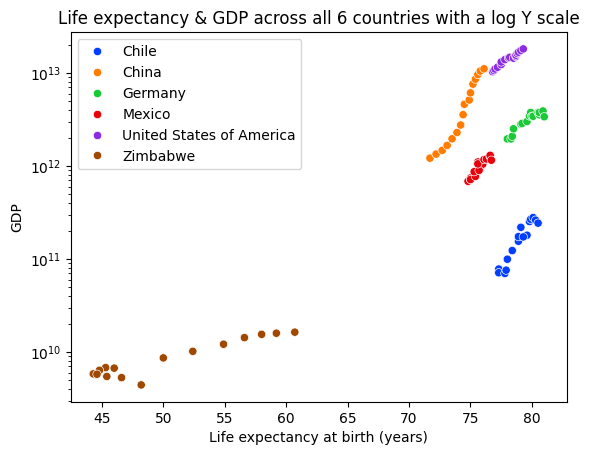

In [10]:
#scatter plot with 3 variables to visualize because there are two quantitave varibles: Life expectancy & GDP & one 
plt.yscale('log')
sns.scatterplot(x=df['Life expectancy at birth (years)'], y=df['GDP'], hue=df['Country'], palette = 'bright')
plt.title('Life expectancy & GDP across all 6 countries with a log Y scale')
plt.legend()
plt.show()

#### Life expectancy change over the years for all countries

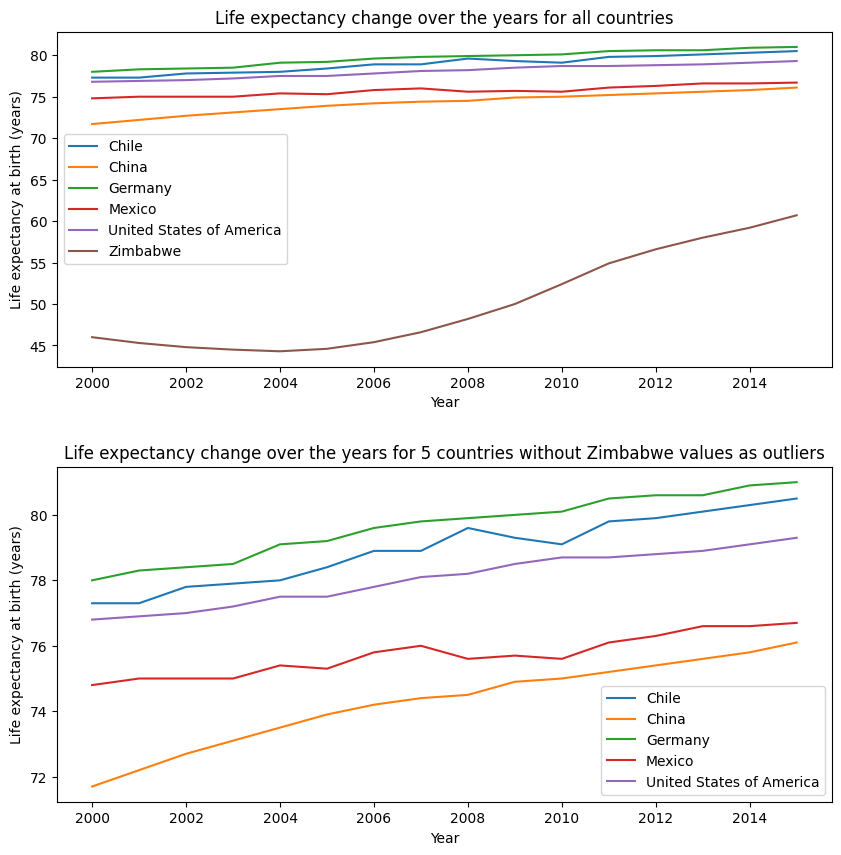

The difference between max and min values of life expectancy for each country
Chile 3.2
China 4.4
Germany 3.0
Mexico 1.9
USA 2.5
Zimbabwe 16.4


In [11]:
#line plot to see the changes 
plt.figure(figsize=(10,10))
plt.subplot (2,1,1)
sns.lineplot(data = df, x=df['Year'], y=df['Life expectancy at birth (years)'], hue = df['Country'])
plt.title('Life expectancy change over the years for all countries')
plt.legend()

#without Zimbabwe as an outlier
#df without Zimbabwe
five_countries = df[df.Country != 'Zimbabwe']
#plot
plt.subplot (2,1,2)
sns.lineplot(data = five_countries, x=five_countries['Year'], y=five_countries['Life expectancy at birth (years)'], hue = five_countries['Country'])
plt.title('Life expectancy change over the years for 5 countries without Zimbabwe values as outliers')
plt.legend()
plt.subplots_adjust(wspace = 0.6)
plt.subplots_adjust(hspace = 0.3)
plt.show()

#max and min values difference to see the level of changes for the countries
print('The difference between max and min values of life expectancy for each country')
countries = [Chile, China, Germany, Mexico, US, Zimbabwe]
names = ['Chile', 'China', 'Germany', 'Mexico', 'USA', 'Zimbabwe']
n = 0
for country in countries:
    difference = country['Life expectancy at birth (years)'].max() - country['Life expectancy at birth (years)'].min()
    print(names[n], round(difference,2))
    n+=1

##### Comments
* It is clear from the first plot that life expectancy is mostly increasing over the years. However, Zimbabwe's values are outliers, so the second plot, excluding Zimbabwe, is shown below for a more detailed picture of the other 5 countries. 
* The second plot shows the following interesting points:
  - Chinese life expectancy growth was rather fast, starting from 2000 until 2008, where the tempo became slower but it is still a leader in life expectancy growth among all 5 countries.
  - The Mexican tempo of life expectancy growth is the lowest among all 5 countries and has changed in about 1.5 years (1.9) during the 15 years.
  - Chile & Germany are the leaders in the life expectancy values and are the only countries from the research that have life expectancy for 2015 is 80+ years.

In [12]:
countries = [Chile, China, Germany, Mexico, US, Zimbabwe]
names = ['Chile', 'China', 'Germany', 'Mexico', 'USA', 'Zimbabwe']
print('Correlation values for Life expectancy and GDP by country')
for n in range(len(countries)):
    corr_var1_var2, p = pearsonr(countries[n]['Life expectancy at birth (years)'], countries[n]['GDP'])
    print(names[n], corr_var1_var2)


Correlation values for Life expectancy and GDP by country
Chile 0.9498766659254412
China 0.9085255408648357
Germany 0.9326988982561272
Mexico 0.9322377167847082
USA 0.9817092382430257
Zimbabwe 0.9661998955858779


#### GDP change over years for all countries

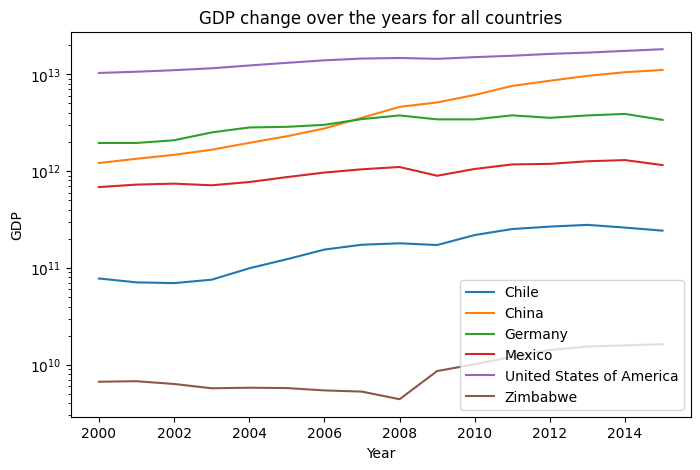

In [13]:
#line plot to see the GDP changes year by year for each country
plt.figure(figsize=(8,5))
plt.yscale('log')
sns.lineplot(data = df, x=df['Year'], y=df['GDP'], hue = df['Country'])
plt.title('GDP change over the years for all countries')
plt.legend()
plt.show()

##### Comments
* From the plot above, we can clearly see that China has made a great effort and has almost reached the leader in GDP value from our list - the USA, even though its position at the beginning of our research (in 2000) was lower than that of Germany. 
* German and Mexican GDP have not changed a lot during the research period, especially after 2008
* Chile and Zimbabwe have an increase in GDP value starting from 2009 and 2008. Zimbabwe also shows negative dynamics in the change in GDP over the 2000-2008 period. 

In [14]:
#create subsets for each country after 2008
Chile2008 = df[(df.Country == 'Chile') & (df.Year > 2007)]
Mexico2008 = df[(df.Country == 'Mexico') & (df.Year > 2007)]
Germany2008 = df[(df.Country == 'Germany')& (df.Year > 2007)]

#create subsets for each country before 2008
Chile2000 = df[(df.Country == 'Chile') & (df.Year < 2008)]
Mexico2000 = df[(df.Country == 'Mexico') & (df.Year < 2008)]
Germany2000 = df[(df.Country == 'Germany')& (df.Year < 2008)]

In [15]:
countries = [Chile2008, Chile2000, Germany2008, Germany2000, Mexico2008, Mexico2000]
names = ['Chile 2008-2015', 'Chile 2000-2008','Germany 2008-2015', 'Germany 2000-2008', 'Mexico 2008-2015', 'Mexico 2000-2008']
print('Correlation values for Life expectancy and GDP by country after 2007')
for n in range(len(countries)):
    corr_var1_var2, p = pearsonr(countries[n]['Life expectancy at birth (years)'], countries[n]['GDP'])
    print(names[n], corr_var1_var2)

Correlation values for Life expectancy and GDP by country after 2007
Chile 2008-2015 0.6589604887325945
Chile 2000-2008 0.9284185579450092
Germany 2008-2015 0.16137593047571308
Germany 2000-2008 0.9657138708513937
Mexico 2008-2015 0.7651810318743294
Mexico 2000-2008 0.9608247732893891


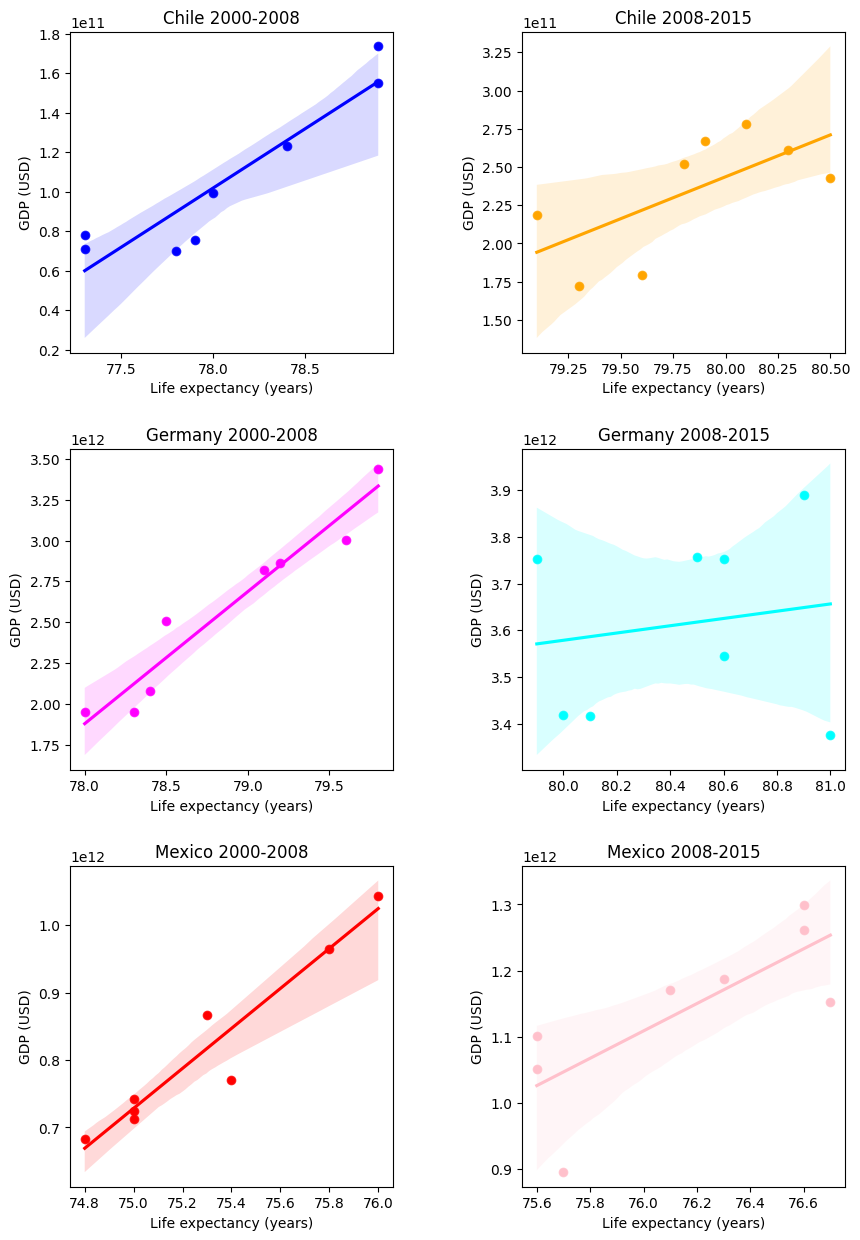

In [16]:
#scatter plot to visualize because there are two quantitave varibles: Life expectancy & GDP
#create scatter plots at subplots for each separate country starting from 2008
countries = [Chile2000, Chile2008, Germany2000, Germany2008, Mexico2000, Mexico2008]
names = ['Chile 2000-2008', 'Chile 2008-2015', 'Germany 2000-2008', 'Germany 2008-2015', 'Mexico 2000-2008', 'Mexico 2008-2015']
colors = ['blue', 'orange', 'magenta', 'cyan', 'red', 'pink']
fig = plt.figure(figsize=(10,15))
n=1
for country in countries:
    plt.subplot(3,2,n)
    sns.scatterplot(x=country['Life expectancy at birth (years)'], y=country['GDP'], color = colors[n-1])
    sns.regplot(x=country['Life expectancy at birth (years)'], y=country['GDP'], data=country, color = colors[n-1])
    plt.xlabel('Life expectancy (years)')
    plt.ylabel('GDP (USD)')
    plt.title(names[n-1])
    n+=1
plt.subplots_adjust(wspace = 0.4)
plt.subplots_adjust(hspace = 0.3)
plt.show()

##### Comments
* From the plots above we can clearly see that in 2000-2008 period the correlation between  GDP value and Life Expectancy was very strong and positive for all of three countries (Chile, Germany and Mexico)
* As for the period of 2008-2015, the correlation for Mexico and Chile has became weaker but still remains strong.
* For German GDP and Life Expetcancy values correlation over the 2008-2015 period, it has almost disappeared (almost horizontal line on the plot and just 0.16 value of Pearson Correlation.)

In [17]:
#create subsets for Zimbabwe before 2008 and after
Zimbabwe2000_2008 = df[(df.Country == 'Zimbabwe') & (df.Year < 2008)]
Zimbabwe2008_2015 = df[(df.Country == 'Zimbabwe') & (df.Year >= 2008)]

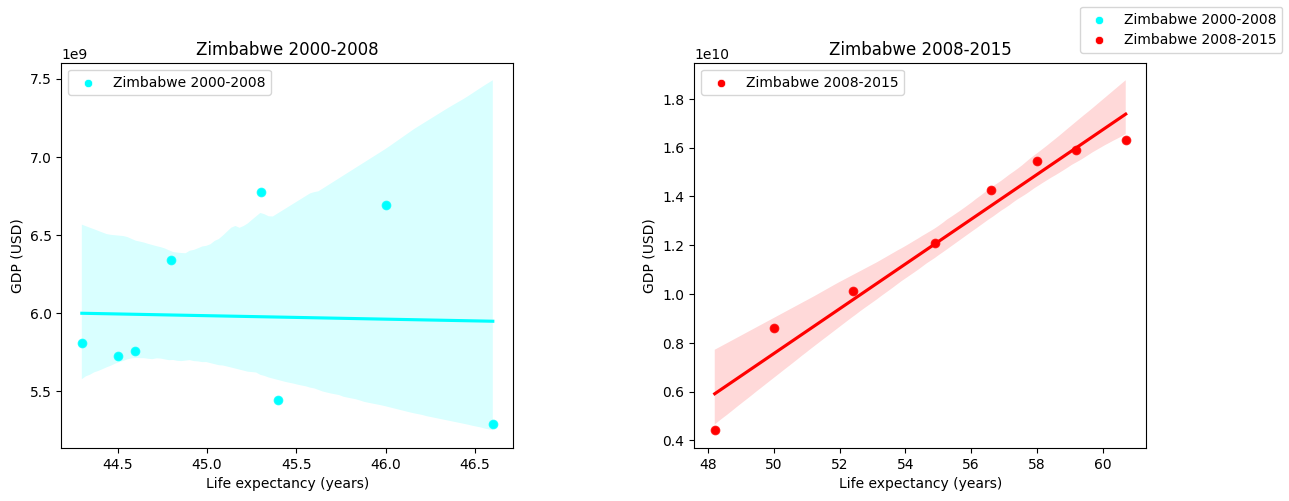

In [18]:
data = [Zimbabwe2000_2008, Zimbabwe2008_2015]
names = ['Zimbabwe 2000-2008','Zimbabwe 2008-2015']
colors = ['cyan', 'red']
fig = plt.figure(figsize=(14,5))
n=1
for dataset in data:
    plt.subplot(1,2,n)
    sns.scatterplot(x=dataset['Life expectancy at birth (years)'], y=dataset['GDP'], color = colors[n-1], label = names[n-1])
    sns.regplot(x=dataset['Life expectancy at birth (years)'], y=dataset['GDP'], data=country, color = colors[n-1])
    plt.xlabel('Life expectancy (years)')
    plt.ylabel('GDP (USD)')
    plt.title(names[n-1])
    n+=1
plt.subplots_adjust(wspace = 0.4)
plt.subplots_adjust(hspace = 0.3)
fig.legend(loc=1)
plt.show()

In [19]:
#Zimbabwe2000-2007(included)
corr_var1_var2, p = pearsonr(Zimbabwe2000_2008['Life expectancy at birth (years)'], Zimbabwe2000_2008['GDP'])
print('Zimbabwe2000-2008', corr_var1_var2)
#Zimbabwe2008-20015
corr_var1_var2, p = pearsonr(Zimbabwe2008_2015['Life expectancy at birth (years)'], Zimbabwe2008_2015['GDP'])
print('Zimbabwe2008-2015', corr_var1_var2)

Zimbabwe2000-2008 -0.031806310078956006
Zimbabwe2008-2015 0.9779335006686506


##### Comments
Zimbabwe has been taken as an outlier for the deeper separate research. 
* From  the plots above, we can see that in the 2000-2008 period, the correlation between GDP and Life Expectancy in this country was absent (almost a horizontal trend line on a scatter plot, and almost 0 (-0.03) value of Pearson Correlation).
* As for the 2008-2015 period, there is a strong positive correlation and rapid growth of both values over the years. 

### Conclusions

After the research has been finished, several main conclusions can be made:
* GDP and Life Expectancy values for almost all countries from the list are positively correlated if we are talking about the whole time period of 2000-2015.
* The bigger size of GDP does not usually mean the big life expectancy values(USA and China vs Germany and Chile as a good example). It might be better to use another metric, such as GDP per capita, if we would like to make a comparison between countries.
* The 2008 Financial Crisis has affected the relationship between GDP and Life Expectancy values for some countries: for Chile and Mexico, the correlation has become weaker, and for Germany, it has almost gone.
* If we are talking about Zimbabwe as an outlier, after 2008, there is a very strong positive correlation between GDP and Life Expectancy, but before, there was almost no correlation between those two values. 
* Life Expectancy value is also steadily increasing in all of our countries from the research over the years. However, the tempo is rather low for almost all of the countries (China, with a 4.4-year life expectancy change between 2000 and 2015, is the leader), except Zimbabwe, with more than 16 years of positive difference between 2000 and 2015 life expectancy values. Zimbabwe's rapid growth might also be the result of a low starting position in life expectancy compared to other countries from the research. 
  